## Glyph Plots / Chernoff Faces — Complete Guide
🔹 What are Glyphs / Chernoff Faces?

A glyph plot represents multidimensional data using visual symbols.
Each feature controls a visual attribute.

🎭 Chernoff Faces

A special glyph type where:

Each data dimension controls a facial feature

Humans are very good at detecting facial differences

Useful for pattern recognition & comparison

### Required Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Arc, Circle


### VARIATION 1 — Basic Glyph (Single Chernoff Face)

In [2]:
def draw_face(ax, features):
    face_w, face_h = features[0], features[1]
    eye_size = features[2]
    eye_sep = features[3]
    mouth_curve = features[4]

    # Face
    face = Ellipse((0, 0), face_w, face_h, fill=False, linewidth=2)
    ax.add_patch(face)

    # Eyes
    ax.add_patch(Circle((-eye_sep, 0.3), eye_size))
    ax.add_patch(Circle(( eye_sep, 0.3), eye_size))

    # Mouth
    mouth = Arc((0, -0.3), 1.0, 0.5,
                theta1=200 - mouth_curve,
                theta2=340 + mouth_curve,
                linewidth=2)
    ax.add_patch(mouth)

    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.axis("off")


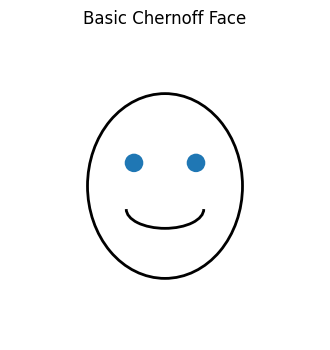

In [3]:
fig, ax = plt.subplots(figsize=(4, 4))
features = [2.0, 2.4, 0.12, 0.4, 20]
draw_face(ax, features)
plt.title("Basic Chernoff Face")
plt.show()


### VARIATION 2 — Normalized Data → Face Parameters

In [4]:
def normalize(x, min_val, max_val, out_min, out_max):
    return out_min + (x - min_val) * (out_max - out_min) / (max_val - min_val)


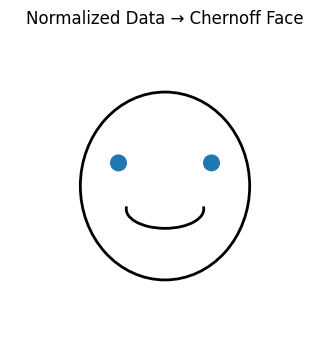

In [5]:
data = np.array([65, 120, 40, 80, 90])  # example features

mapped = [
    normalize(data[0], 0, 100, 1.6, 2.5),  # face width
    normalize(data[1], 0, 150, 1.8, 2.6),  # face height
    normalize(data[2], 0, 100, 0.05, 0.2), # eye size
    normalize(data[3], 0, 100, 0.2, 0.7),  # eye spacing
    normalize(data[4], 0, 100, -30, 30)   # mouth curve
]

fig, ax = plt.subplots(figsize=(4, 4))
draw_face(ax, mapped)
plt.title("Normalized Data → Chernoff Face")
plt.show()


### VARIATION 3 — Grid of Chernoff Faces (Dataset View)

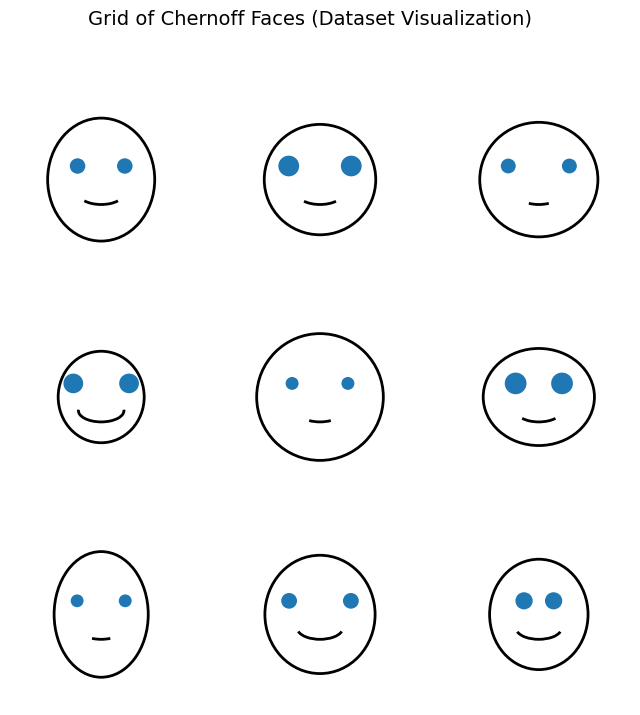

In [6]:
np.random.seed(0)
data = np.random.rand(9, 5)

fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    features = [
        1.8 + data[i,0],
        2.0 + data[i,1],
        0.05 + data[i,2]*0.2,
        0.3 + data[i,3]*0.4,
        -30 + data[i,4]*60
    ]
    draw_face(ax, features)

plt.suptitle("Grid of Chernoff Faces (Dataset Visualization)", fontsize=14)
plt.show()


### VARIATION 4 — Chernoff Faces with Labels

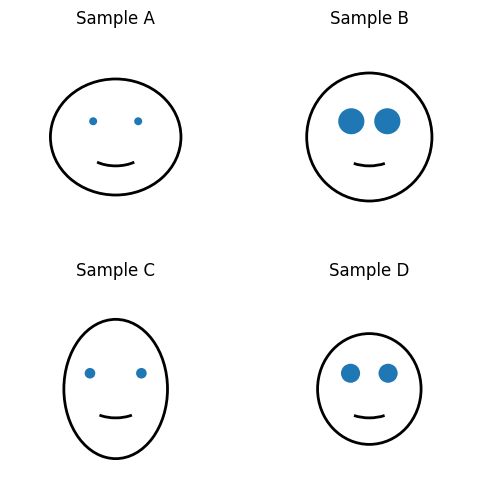

In [7]:
labels = ["A", "B", "C", "D"]

fig, axes = plt.subplots(2, 2, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    features = np.random.rand(5)
    features = [
        1.8 + features[0],
        2.0 + features[1],
        0.05 + features[2]*0.2,
        0.3 + features[3]*0.4,
        -25 + features[4]*50
    ]
    draw_face(ax, features)
    ax.set_title(f"Sample {labels[i]}")

plt.show()


### VARIATION 5 — Color-Encoded Glyphs

In [8]:
def draw_face_colored(ax, features, color):
    draw_face(ax, features)
    for patch in ax.patches:
        patch.set_edgecolor(color)


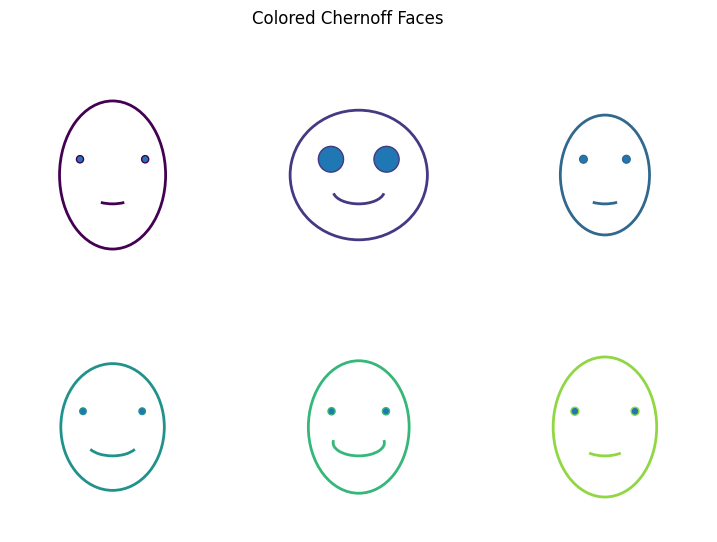

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(9, 6))

for i, ax in enumerate(axes.flat):
    feats = np.random.rand(5)
    mapped = [
        1.7 + feats[0],
        2.0 + feats[1],
        0.05 + feats[2]*0.2,
        0.3 + feats[3]*0.4,
        -30 + feats[4]*60
    ]
    color = plt.cm.viridis(i / 6)
    draw_face_colored(ax, mapped, color)

plt.suptitle("Colored Chernoff Faces")
plt.show()


### VARIATION 6 — Emotion-Based Faces

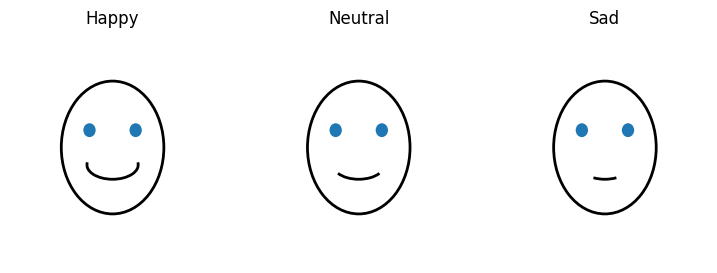

In [10]:
emotions = {
    "happy":  25,
    "neutral": 0,
    "sad": -25
}

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

for ax, (name, curve) in zip(axes, emotions.items()):
    features = [2, 2.3, 0.12, 0.45, curve]
    draw_face(ax, features)
    ax.set_title(name.capitalize())

plt.show()


### VARIATION 7 — Chernoff Faces from Pandas DataFrame

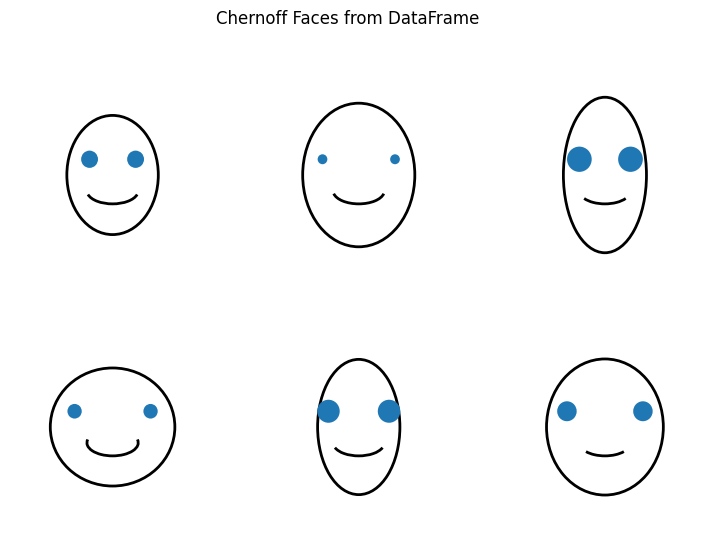

In [11]:
df = pd.DataFrame({
    "A": np.random.rand(6),
    "B": np.random.rand(6),
    "C": np.random.rand(6),
    "D": np.random.rand(6),
    "E": np.random.rand(6),
})

fig, axes = plt.subplots(2, 3, figsize=(9, 6))

for i, ax in enumerate(axes.flat):
    row = df.iloc[i]
    features = [
        1.6 + row.A,
        2.0 + row.B,
        0.05 + row.C * 0.2,
        0.3 + row.D * 0.5,
        -30 + row.E * 60
    ]
    draw_face(ax, features)

plt.suptitle("Chernoff Faces from DataFrame")
plt.show()


### VARIATION 8 — Cluster Visualization using Faces

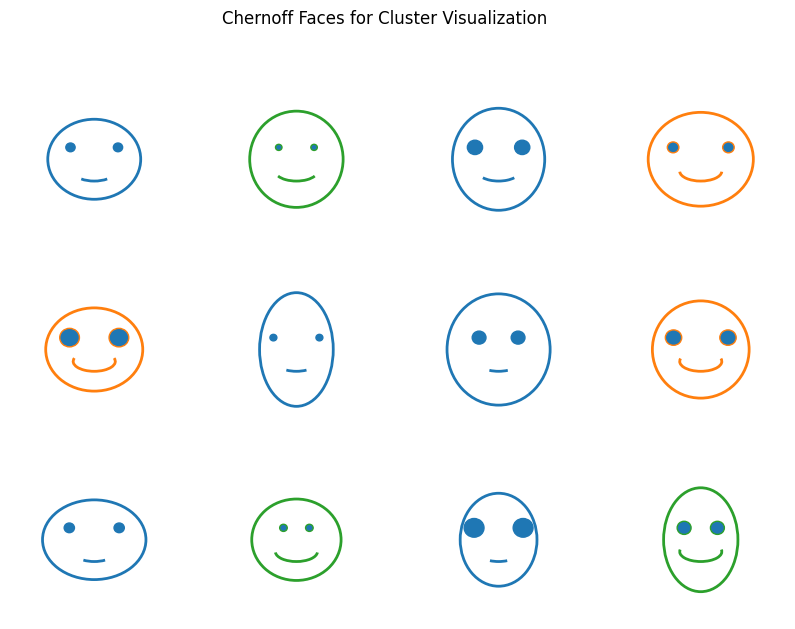

In [12]:
from sklearn.cluster import KMeans

data = np.random.rand(12, 5)
labels = KMeans(n_clusters=3, random_state=0).fit_predict(data)

fig, axes = plt.subplots(3, 4, figsize=(10, 7))

for i, ax in enumerate(axes.flat):
    f = data[i]
    features = [
        1.6 + f[0],
        2.0 + f[1],
        0.05 + f[2]*0.2,
        0.3 + f[3]*0.4,
        -30 + f[4]*60
    ]
    color = plt.cm.tab10(labels[i])
    draw_face_colored(ax, features, color)

plt.suptitle("Chernoff Faces for Cluster Visualization")
plt.show()


### VARIATION 9 — Animated Chernoff Face (Time Series)

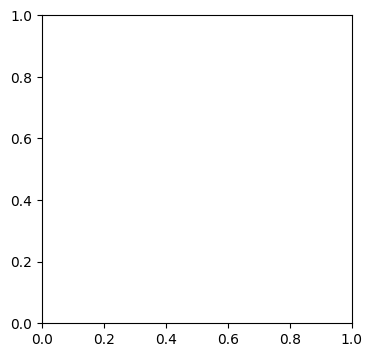

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation

fig, ax = plt.subplots(figsize=(4, 4))

# ---- draw function reused ----
def draw_face(ax, features):
    face_w, face_h, eye_size, eye_sep, mouth_curve = features

    from matplotlib.patches import Ellipse, Circle, Arc

    face = Ellipse((0, 0), face_w, face_h, fill=False, linewidth=2)
    ax.add_patch(face)

    ax.add_patch(Circle((-eye_sep, 0.3), eye_size))
    ax.add_patch(Circle(( eye_sep, 0.3), eye_size))

    mouth = Arc(
        (0, -0.3),
        1.0, 0.5,
        theta1=200 - mouth_curve,
        theta2=340 + mouth_curve,
        linewidth=2
    )
    ax.add_patch(mouth)


# ---- animation update ----
def update(frame):
    ax.clear()

    f = np.sin(frame / 10) * 0.5 + 0.5

    features = [
        1.8 + f,
        2.1,
        0.1,
        0.4,
        -30 + 60 * f
    ]

    draw_face(ax, features)
    ax.set_title(f"Time = {frame}")
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.axis("off")

    return ax.patches


# IMPORTANT: keep animation reference alive
ani = animation.FuncAnimation(
    fig,
    update,
    frames=60,
    interval=100,
    blit=False
)

plt.show()


In [19]:
ani.save("gifs/chernoff_face_animation.gif", writer="pillow", fps=10)


### VARIATION 10 — Glyphs Beyond Faces (Generic Glyph Plot)

In [15]:
def radial_glyph(ax, values):
    angles = np.linspace(0, 2*np.pi, len(values), endpoint=False)
    values = np.append(values, values[0])
    angles = np.append(angles, angles[0])

    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.3)
